# AIN-2002 Homework 3

## Learning Analytics: Data Preparation, Classification, Clustering and PCA

## Task 1 - Setup and Data Inspection

In [143]:

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning & preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Regex
import re

# Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Visualization style
sns.set(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [144]:
# Create dataset

rng = np.random.default_rng(2026)
n = 90
student_ids = np.arange(3001, 3001 + n)

df_hw3 = pd.DataFrame({

    "Student_ID": student_ids,

    "Department": rng.choice(
        [
            "AIE",
            "aie ",
            "Artificial Intelligence Engineering",
            "SE",
            "software engineering",
            "CE",
            "Computer Eng."
        ],
        size=n,
        replace=True,
        p=[0.30, 0.05, 0.05, 0.25, 0.05, 0.25, 0.05]
    ),

    "Study_Hours": np.round(
        rng.normal(loc=13, scale=4, size=n), 1
    ),

    "Sleep_Hours": np.round(
        rng.normal(loc=7, scale=1.2, size=n), 1
    ),

    "Attendance_Rate": np.round(
        rng.uniform(low=0.45, high=1.00, size=n), 2
    ),

    "LMS_Clicks": rng.poisson(
        lam=120,
        size=n
    ),

    "Video_Minutes": np.round(
        rng.normal(loc=260, scale=80, size=n), 0
    ),

    "Forum_Posts": rng.poisson(
        lam=4,
        size=n
    ),

    "Teaching_Method": rng.choice(
        [
            "Traditional",
            "Flipped",
            "Project-Based"
        ],
        size=n,
        replace=True,
        p=[0.35, 0.35, 0.30]
    ),

    "Quiz_Score": np.round(
        rng.normal(loc=72, scale=12, size=n), 0
    ),

    "Project_Score": np.round(
        rng.normal(loc=78, scale=10, size=n), 0
    ),

    "Advisor_Email": [
        f"student{i}@bahcesehir.edu.tr"
        for i in student_ids
    ]
})


# Add missing values

df_hw3.loc[[2, 17, 46], "Study_Hours"] = np.nan
df_hw3.loc[[10, 51], "Sleep_Hours"] = np.nan
df_hw3.loc[[6, 32], "Attendance_Rate"] = np.nan
df_hw3.loc[20, "Quiz_Score"] = np.nan
df_hw3.loc[43, "Project_Score"] = np.nan


# Add inconsistent category labels

df_hw3.loc[[4, 24, 43], "Department"] = [
    "aie ",
    "SE ",
    "computer eng."
]

df_hw3.loc[[8, 38, 69], "Teaching_Method"] = [
    "flipped ",
    "PROJECT-based",
    "traditional"
]


# Add invalid email values

df_hw3.loc[[11, 35], "Advisor_Email"] = [
    "student3012[at]bahcesehir.edu.tr",
    "student3036@invalid"
]


# Add impossible or extreme values

df_hw3.loc[79, "Student_ID"] = df_hw3.loc[9, "Student_ID"]

df_hw3.loc[15, "Attendance_Rate"] = 1.25
df_hw3.loc[27, "Study_Hours"] = -4
df_hw3.loc[40, "Sleep_Hours"] = 18
df_hw3.loc[63, "Quiz_Score"] = 132
df_hw3.loc[72, "Project_Score"] = -15
df_hw3.loc[54, "Video_Minutes"] = 980


# Create outcome variables before cleaning

df_hw3["Overall_Score"] = np.round(
    0.40 * df_hw3["Quiz_Score"] +
    0.40 * df_hw3["Project_Score"] +
    0.20 * (100 * df_hw3["Attendance_Rate"]),
    0
)

df_hw3["Success_Status"] = np.where(
    df_hw3["Overall_Score"] >= 75,
    "Successful",
    "At_Risk"
)


# Add duplicated rows

df_hw3 = pd.concat(
    [df_hw3, df_hw3.loc[[5, 13]]],
    ignore_index=True
)

print("Dataset created.")

Dataset created.


In [145]:
# Show the first six rows
# This helps us see the columns and the general shape of the data

df_hw3.head(6)

,Student_ID,Department,Study_Hours,Sleep_Hours,Attendance_Rate,LMS_Clicks,Video_Minutes,Forum_Posts,Teaching_Method,Quiz_Score,Project_Score,Advisor_Email,Overall_Score,Success_Status
0,3001,AIE,14.9,8.6,0.68,110,338.0,2,Traditional,75.0,72.0,student3001@bahcesehir.edu.tr,72.0,At_Risk
1,3002,SE,14.5,6.0,0.87,103,151.0,8,Traditional,75.0,89.0,student3002@bahcesehir.edu.tr,83.0,Successful
2,3003,SE,NaN,4.9,0.54,119,110.0,0,Flipped,67.0,111.0,student3003@bahcesehir.edu.tr,82.0,Successful
3,3004,Artificial Intelligence Engineering,10.3,8.7,0.51,107,256.0,2,Project-Based,76.0,79.0,student3004@bahcesehir.edu.tr,72.0,At_Risk
4,3005,aie,12.2,6.5,0.83,115,109.0,2,Flipped,70.0,83.0,student3005@bahcesehir.edu.tr,78.0,Successful
5,3006,CE,9.6,7.1,0.94,125,238.0,8,Flipped,63.0,69.0,student3006@bahcesehir.edu.tr,72.0,At_Risk


In [146]:
# Check the structure of the dataset
# This shows column names, data types, non-null counts, and memory usage

df_hw3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       92 non-null     int64  
 1   Department       92 non-null     object 
 2   Study_Hours      89 non-null     float64
 3   Sleep_Hours      90 non-null     float64
 4   Attendance_Rate  90 non-null     float64
 5   LMS_Clicks       92 non-null     int64  
 6   Video_Minutes    92 non-null     float64
 7   Forum_Posts      92 non-null     int64  
 8   Teaching_Method  92 non-null     object 
 9   Quiz_Score       91 non-null     float64
 10  Project_Score    91 non-null     float64
 11  Advisor_Email    92 non-null     object 
 12  Overall_Score    88 non-null     float64
 13  Success_Status   92 non-null     object 
dtypes: float64(7), int64(3), object(4)
memory usage: 10.2+ KB


In [147]:
# Show summary statistics for numeric columns
# This helps us detect strange minimum and maximum values

df_hw3.describe()

,Student_ID,Study_Hours,Sleep_Hours,Attendance_Rate,LMS_Clicks,Video_Minutes,Forum_Posts,Quiz_Score,Project_Score,Overall_Score
count,92.000000,89.000000,90.000000,90.000000,92.000000,92.000000,92.000000,91.000000,91.000000,88.000000
mean,3043.967391,13.110112,7.204444,0.747222,119.032609,271.945652,4.206522,73.285714,76.241758,74.761364
std,26.342816,4.855293,1.707940,0.165190,11.191098,111.307155,2.161288,12.664285,13.919084,8.470360
min,3001.000000,-4.000000,2.500000,0.460000,89.000000,97.000000,0.000000,40.000000,-15.000000,34.000000
25%,3020.750000,9.600000,6.325000,0.622500,110.000000,212.250000,2.750000,65.500000,70.000000,71.000000
50%,3043.500000,13.500000,7.100000,0.735000,120.000000,265.500000,4.000000,73.000000,78.000000,74.000000
75%,3066.250000,16.200000,7.900000,0.880000,126.000000,317.250000,6.000000,78.000000,82.000000,79.250000
max,3090.000000,24.700000,18.000000,1.250000,147.000000,980.000000,9.000000,132.000000,111.000000,102.000000


In [148]:
# Count missing values in each column
# Missing values must be handled before modeling

missing_values = df_hw3.isnull().sum()

missing_values

Student_ID         0
Department         0
Study_Hours        3
Sleep_Hours        2
Attendance_Rate    2
LMS_Clicks         0
Video_Minutes      0
Forum_Posts        0
Teaching_Method    0
Quiz_Score         1
Project_Score      1
Advisor_Email      0
Overall_Score      4
Success_Status     0
dtype: int64

In [149]:
# Find duplicated Student_ID values
# A student ID should normally be unique

duplicated_student_ids = df_hw3[
    df_hw3["Student_ID"].duplicated(keep=False)
].sort_values("Student_ID")

duplicated_student_ids

,Student_ID,Department,Study_Hours,Sleep_Hours,Attendance_Rate,LMS_Clicks,Video_Minutes,Forum_Posts,Teaching_Method,Quiz_Score,Project_Score,Advisor_Email,Overall_Score,Success_Status
5,3006,CE,9.6,7.1,0.94,125,238.0,8,Flipped,63.0,69.0,student3006@bahcesehir.edu.tr,72.0,At_Risk
90,3006,CE,9.6,7.1,0.94,125,238.0,8,Flipped,63.0,69.0,student3006@bahcesehir.edu.tr,72.0,At_Risk
79,3010,AIE,16.8,6.7,0.61,121,262.0,1,Flipped,65.0,68.0,student3080@bahcesehir.edu.tr,65.0,At_Risk
9,3010,AIE,5.8,8.3,0.74,140,302.0,2,Project-Based,76.0,75.0,student3010@bahcesehir.edu.tr,75.0,Successful
13,3014,CE,11.5,7.9,0.95,126,497.0,8,Flipped,72.0,78.0,student3014@bahcesehir.edu.tr,79.0,Successful
91,3014,CE,11.5,7.9,0.95,126,497.0,8,Flipped,72.0,78.0,student3014@bahcesehir.edu.tr,79.0,Successful


In [150]:
# Show unique Department labels before cleaning
# This helps us see spelling, spacing, and case problems

df_hw3["Department"].unique()

array(['AIE', 'SE', 'Artificial Intelligence Engineering', 'aie ', 'CE',
       'software engineering', 'Computer Eng.', 'SE ', 'computer eng.'],
      dtype=object)

In [151]:
# Show unique Teaching_Method labels before cleaning
# This helps us detect inconsistent category labels

df_hw3["Teaching_Method"].unique()

array(['Traditional', 'Flipped', 'Project-Based', 'flipped ',
       'PROJECT-based', 'traditional'], dtype=object)

### Initial Data Inspection

The dataset contains student-level learning analytics variables such as study hours, sleep hours, attendance rate, LMS clicks, video minutes, forum posts, quiz score, project score, teaching method, department, and success status.

The first inspection shows that the dataset includes missing values, duplicated student IDs, inconsistent categorical labels, invalid e-mail strings, and logically impossible numerical values. Therefore, the dataset must be cleaned before exploratory analysis, PCA, classification, and clustering.

## Task 2 - Data Cleaning and Preparation

In [152]:
# Replace impossible Study_Hours values with NaN
# Study hours cannot be negative

df_hw3.loc[
    df_hw3["Study_Hours"] < 0,
    "Study_Hours"
] = np.nan

In [153]:
# Replace unrealistic Sleep_Hours values with NaN
# Sleep hours outside realistic range are treated as invalid

df_hw3.loc[
    (df_hw3["Sleep_Hours"] < 3) |
    (df_hw3["Sleep_Hours"] > 12),
    "Sleep_Hours"
] = np.nan

In [154]:
# Replace invalid Attendance_Rate values with NaN
# Attendance rate must be between 0 and 1

df_hw3.loc[
    (df_hw3["Attendance_Rate"] < 0) |
    (df_hw3["Attendance_Rate"] > 1),
    "Attendance_Rate"
] = np.nan

In [155]:
# Replace invalid Quiz_Score values with NaN
# Scores must be between 0 and 100

df_hw3.loc[
    (df_hw3["Quiz_Score"] < 0) |
    (df_hw3["Quiz_Score"] > 100),
    "Quiz_Score"
] = np.nan

In [156]:
# Replace invalid Project_Score values with NaN

df_hw3.loc[
    (df_hw3["Project_Score"] < 0) |
    (df_hw3["Project_Score"] > 100),
    "Project_Score"
] = np.nan

In [157]:
# Detect extreme Video_Minutes values using IQR

Q1 = df_hw3["Video_Minutes"].quantile(0.25)
Q3 = df_hw3["Video_Minutes"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

54.75
474.75


In [158]:
# Replace extreme Video_Minutes values with NaN

df_hw3.loc[
    (df_hw3["Video_Minutes"] < lower_bound) |
    (df_hw3["Video_Minutes"] > upper_bound),
    "Video_Minutes"
] = np.nan

In [159]:
# Fill missing numeric values with median
# Median is more robust to outliers than mean

numeric_columns = [

    "Study_Hours",
    "Sleep_Hours",
    "Attendance_Rate",
    "Quiz_Score",
    "Project_Score",
    "Video_Minutes"
]

for column in numeric_columns:

    median_value = df_hw3[column].median()

    df_hw3[column] = df_hw3[column].fillna(
        median_value
    )

In [160]:
# Check missing values after cleaning

df_hw3.isnull().sum()

Student_ID         0
Department         0
Study_Hours        0
Sleep_Hours        0
Attendance_Rate    0
LMS_Clicks         0
Video_Minutes      0
Forum_Posts        0
Teaching_Method    0
Quiz_Score         0
Project_Score      0
Advisor_Email      0
Overall_Score      4
Success_Status     0
dtype: int64

In [161]:
# Check summary statistics after cleaning

df_hw3.describe()

,Student_ID,Study_Hours,Sleep_Hours,Attendance_Rate,LMS_Clicks,Video_Minutes,Forum_Posts,Quiz_Score,Project_Score,Overall_Score
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,88.000000
mean,3043.967391,13.319565,7.133696,0.741196,119.032609,259.032609,4.206522,72.326087,76.913043,74.761364
std,26.342816,4.421320,1.150850,0.154542,11.191098,74.843493,2.161288,10.523766,9.300422,8.470360
min,3001.000000,3.200000,4.800000,0.460000,89.000000,97.000000,0.000000,40.000000,49.000000,34.000000
25%,3020.750000,10.125000,6.400000,0.627500,110.000000,212.250000,2.750000,65.750000,70.000000,71.000000
50%,3043.500000,13.650000,7.100000,0.730000,120.000000,262.000000,4.000000,73.000000,78.000000,74.000000
75%,3066.250000,16.125000,7.900000,0.880000,126.000000,305.000000,6.000000,78.000000,82.000000,79.250000
max,3090.000000,24.700000,10.000000,1.000000,147.000000,466.000000,9.000000,98.000000,100.000000,102.000000


### Cleaning Numerical Variables

Impossible numerical values were converted to missing values before imputation. This approach prevents unrealistic observations from distorting the analysis.

Median imputation was used because the median is less sensitive to extreme values and outliers compared to the mean. This makes the cleaned dataset more robust for PCA, classification, and clustering.

## Task 3 - Feature Engineering and Transformation

In [162]:
# Recalculate Overall_Score after cleaning

df_hw3["Overall_Score"] = np.round(

    0.40 * df_hw3["Quiz_Score"] +

    0.40 * df_hw3["Project_Score"] +

    0.20 * (100 * df_hw3["Attendance_Rate"]),

    0
)

In [163]:
# Recreate Success_Status using cleaned scores

df_hw3["Success_Status"] = np.where(

    df_hw3["Overall_Score"] >= 75,

    "Successful",

    "At_Risk"
)

In [164]:
# Create performance categories

conditions = [

    df_hw3["Overall_Score"] >= 85,

    df_hw3["Overall_Score"] >= 70
]

choices = [

    "High",

    "Medium"
]

df_hw3["Performance_Level"] = np.select(

    conditions,

    choices,

    default="Low"
)

In [165]:
# Create engagement bands using LMS_Clicks

df_hw3["Engagement_Band"] = pd.cut(

    df_hw3["LMS_Clicks"],

    bins=3,

    labels=[

        "Low",

        "Medium",

        "High"
    ]
)

In [166]:
# Check new variables

df_hw3[[
    "Overall_Score",
    "Success_Status",
    "Performance_Level",
    "Engagement_Band"
]].head()

,Overall_Score,Success_Status,Performance_Level,Engagement_Band
0,72.0,At_Risk,Medium,Medium
1,83.0,Successful,Medium,Low
2,69.0,At_Risk,Low,Medium
3,72.0,At_Risk,Medium,Low
4,78.0,Successful,Medium,Medium


In [167]:
# Create dummy variables for Department

department_dummies = pd.get_dummies(

    df_hw3["Department"],

    prefix="Dept"
)

department_dummies.head()

,Dept_AIE,Dept_Artificial Intelligence Engineering,Dept_CE,Dept_Computer Eng.,Dept_SE,Dept_SE,Dept_aie,Dept_computer eng.,Dept_software engineering
0,True,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False
2,False,False,False,False,True,False,False,False,False
3,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False


In [168]:
# Create dummy variables for Teaching_Method

teaching_dummies = pd.get_dummies(

    df_hw3["Teaching_Method"],

    prefix="Method"
)

teaching_dummies.head()

,Method_Flipped,Method_PROJECT-based,Method_Project-Based,Method_Traditional,Method_flipped,Method_traditional
0,False,False,False,True,False,False
1,False,False,False,True,False,False
2,True,False,False,False,False,False
3,False,False,True,False,False,False
4,True,False,False,False,False,False


In [169]:
# Define email validation pattern

email_pattern = r"^student\d+@bahcesehir\.edu\.tr$"

In [170]:
# Check whether emails are valid

df_hw3["Valid_Email"] = df_hw3["Advisor_Email"].str.match(

    email_pattern
)

In [171]:
# Show invalid email values

df_hw3.loc[
    ~df_hw3["Valid_Email"],
    "Advisor_Email"
]

11    student3012[at]bahcesehir.edu.tr
35                 student3036@invalid
Name: Advisor_Email, dtype: object

In [172]:
# Extract student number from valid emails

df_hw3["Extracted_ID"] = df_hw3["Advisor_Email"].str.extract(

    r"student(\d+)"
)

In [173]:
# Check extracted IDs

df_hw3[[
    "Advisor_Email",
    "Extracted_ID"
]].head()

,Advisor_Email,Extracted_ID
0,student3001@bahcesehir.edu.tr,3001
1,student3002@bahcesehir.edu.tr,3002
2,student3003@bahcesehir.edu.tr,3003
3,student3004@bahcesehir.edu.tr,3004
4,student3005@bahcesehir.edu.tr,3005


### Feature Engineering

New analytical variables were created after cleaning the dataset. Overall_Score and Success_Status were recalculated using cleaned numerical values.

Performance_Level and Engagement_Band were created to simplify interpretation of student performance and engagement behavior.

Dummy variables were generated to convert categorical variables into machine learning compatible numerical representations.

Regular expressions were used to validate e-mail formats and extract student identifiers from valid e-mail strings.

## Task 4 - Exploratory Data Analysis (EDA)

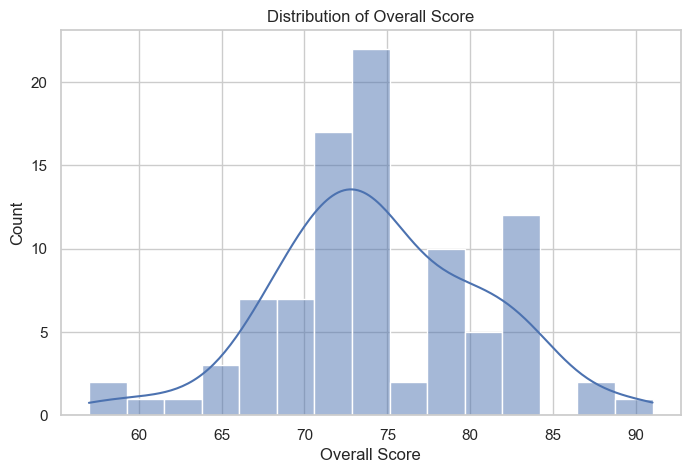

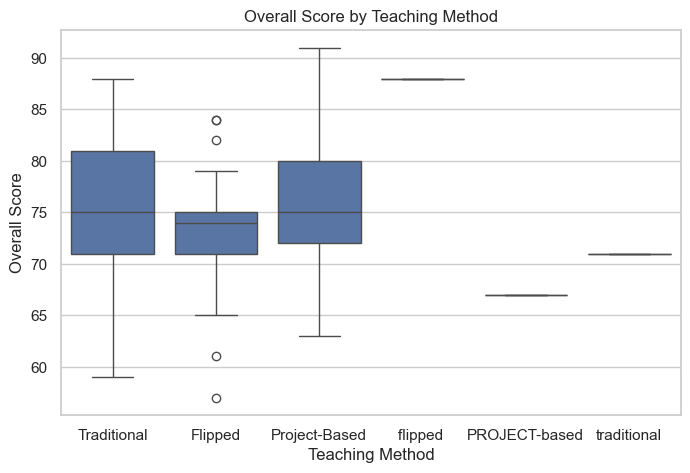

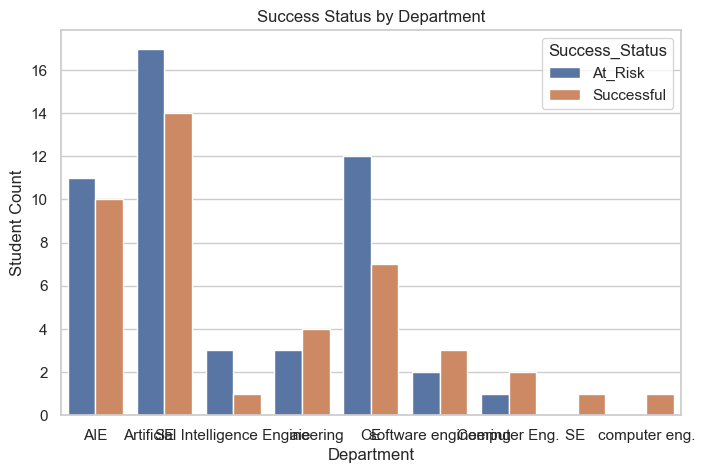

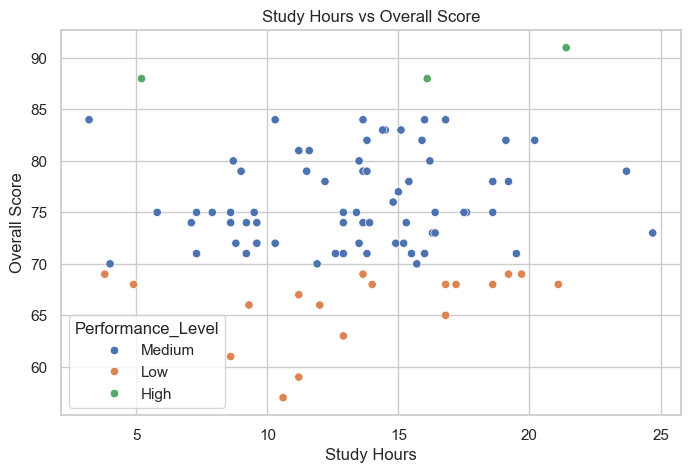

In [174]:
# Histogram of Overall_Score

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_hw3,
    x="Overall_Score",
    bins=15,
    kde=True
)

plt.title("Distribution of Overall Score")
plt.xlabel("Overall Score")
plt.ylabel("Count")

plt.show()



# Boxplot of Overall_Score by Teaching_Method

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_hw3,
    x="Teaching_Method",
    y="Overall_Score"
)

plt.title("Overall Score by Teaching Method")
plt.xlabel("Teaching Method")
plt.ylabel("Overall Score")

plt.show()



# Success_Status count by Department

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_hw3,
    x="Department",
    hue="Success_Status"
)

plt.title("Success Status by Department")
plt.xlabel("Department")
plt.ylabel("Student Count")

plt.show()



# Scatter plot of Study_Hours vs Overall_Score

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_hw3,
    x="Study_Hours",
    y="Overall_Score",
    hue="Performance_Level"
)

plt.title("Study Hours vs Overall Score")
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")

plt.show()

### Interpretation of Visualizations

The histogram of Overall_Score shows that most students are concentrated around the middle and upper score ranges. The distribution appears relatively balanced after data cleaning.

The boxplot suggests that student performance differs across teaching methods. Some methods appear to produce higher median scores and less variability than others.

The bar chart indicates that the proportion of Successful and At_Risk students varies between departments. This may suggest differences in student behavior or academic structure across programs.

The scatter plot shows a generally positive relationship between Study_Hours and Overall_Score. Students who study more tend to achieve higher overall performance, although some variation still exists.

## Task 5 - Principal Component Analysis (PCA)

In [175]:
# Check missing values in PCA variables

pca_features = df_hw3[[
    "Study_Hours",
    "Sleep_Hours",
    "Attendance_Rate",
    "LMS_Clicks",
    "Video_Minutes",
    "Forum_Posts",
    "Quiz_Score",
    "Project_Score"
]]

pca_features.isnull().sum()

Study_Hours        0
Sleep_Hours        0
Attendance_Rate    0
LMS_Clicks         0
Video_Minutes      0
Forum_Posts        0
Quiz_Score         0
Project_Score      0
dtype: int64

In [176]:
# Fill remaining missing values before PCA

pca_numeric_columns = [
    "Study_Hours",
    "Sleep_Hours",
    "Attendance_Rate",
    "LMS_Clicks",
    "Video_Minutes",
    "Forum_Posts",
    "Quiz_Score",
    "Project_Score"
]

for column in pca_numeric_columns:
    df_hw3[column] = df_hw3[column].fillna(df_hw3[column].median())

# Check again
df_hw3[pca_numeric_columns].isnull().sum()

Study_Hours        0
Sleep_Hours        0
Attendance_Rate    0
LMS_Clicks         0
Video_Minutes      0
Forum_Posts        0
Quiz_Score         0
Project_Score      0
dtype: int64

In [177]:
# Select numerical variables for PCA

pca_features = df_hw3[[
    "Study_Hours",
    "Sleep_Hours",
    "Attendance_Rate",
    "LMS_Clicks",
    "Video_Minutes",
    "Forum_Posts",
    "Quiz_Score",
    "Project_Score"
]]


# Standardize the variables before PCA
# PCA is sensitive to scale differences

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    pca_features
)


# Apply PCA

pca = PCA()

pca_components = pca.fit_transform(
    scaled_features
)


# Create explained variance table

explained_variance = pd.DataFrame({

    "Principal_Component": [
        f"PC{i+1}"
        for i in range(len(pca.explained_variance_ratio_))
    ],

    "Explained_Variance_Ratio":
        pca.explained_variance_ratio_
})


# Add cumulative variance

explained_variance["Cumulative_Variance"] = (
    explained_variance["Explained_Variance_Ratio"]
    .cumsum()
)


# Show explained variance results

explained_variance

,Principal_Component,Explained_Variance_Ratio,Cumulative_Variance
0,PC1,0.173852,0.173852
1,PC2,0.160186,0.334038
2,PC3,0.147589,0.481627
3,PC4,0.126332,0.607959
4,PC5,0.122884,0.730843
5,PC6,0.114929,0.845772
6,PC7,0.081544,0.927316
7,PC8,0.072684,1.000000


In [178]:
# PCA loadings
# Loadings show how strongly each variable contributes to components

loadings = pd.DataFrame(

    pca.components_.T,

    columns=[
        f"PC{i+1}"
        for i in range(len(pca.components_))
    ],

    index=pca_features.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Study_Hours,-0.012681,-0.566713,-0.226805,0.382284,0.446114,-0.033091,0.527680,0.050346
Sleep_Hours,0.388935,-0.201236,0.130846,0.035201,-0.422250,0.732406,0.239588,-0.133257
Attendance_Rate,0.612199,-0.103501,0.194084,0.213529,-0.199204,-0.381465,-0.078846,0.582943
LMS_Clicks,0.232132,0.617360,-0.098937,0.392015,-0.103135,-0.228616,0.450124,-0.368787
Video_Minutes,0.485569,0.151302,-0.141119,0.149294,0.607512,0.277182,-0.475032,-0.166045
Forum_Posts,0.317479,-0.376478,-0.455117,-0.301356,-0.258796,-0.370951,-0.131961,-0.487371
Quiz_Score,-0.281203,-0.067806,-0.390162,0.664793,-0.369006,0.101471,-0.415693,0.053744
Project_Score,-0.065199,-0.277973,0.710429,0.313519,0.012480,-0.199936,-0.198631,-0.485687


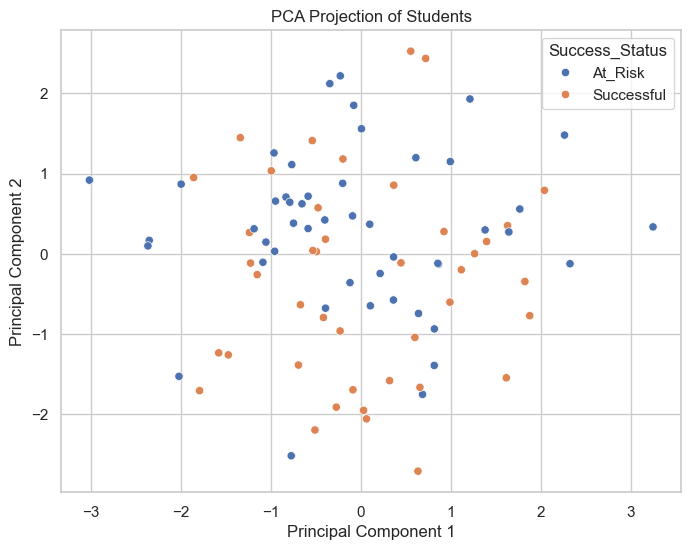

In [179]:
# Create dataframe for PCA visualization

pca_df = pd.DataFrame({

    "PC1": pca_components[:, 0],

    "PC2": pca_components[:, 1],

    "Success_Status":
        df_hw3["Success_Status"]
})


# PCA scatter plot

plt.figure(figsize=(8, 6))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Success_Status"
)

plt.title("PCA Projection of Students")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

### PCA Interpretation

PCA was applied to standardized numerical learning behavior variables in order to reduce dimensionality and identify dominant behavioral patterns among students.

The explained variance ratios show how much information is preserved by each principal component. The first few components capture a meaningful proportion of the total variance in the dataset.

The loading matrix shows which variables contribute most strongly to each principal component. Variables with larger absolute loading values have greater influence on the corresponding component.

The PCA scatter plot suggests partial separation between Successful and At_Risk students in the reduced feature space, indicating that student behavior patterns are related to academic success.

## Task 6 - Classification Modeling

In [180]:
# Select predictor variables

X = df_hw3[[
    "Study_Hours",
    "Attendance_Rate",
    "LMS_Clicks",
    "Video_Minutes",
    "Forum_Posts",
    "Quiz_Score",
    "Project_Score"
]]


# Add dummy variables for categorical features

department_dummies = pd.get_dummies(
    df_hw3["Department"],
    prefix="Dept",
    drop_first=True
)

teaching_dummies = pd.get_dummies(
    df_hw3["Teaching_Method"],
    prefix="Method",
    drop_first=True
)


# Combine all predictors

X = pd.concat(
    [X, department_dummies, teaching_dummies],
    axis=1
)


# Create target variable
# Successful = 1
# At_Risk = 0

y = np.where(
    df_hw3["Success_Status"] == "Successful",
    1,
    0
)


# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.30,

    random_state=2026
)


# Build logistic regression model

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)


# Predict probabilities

y_prob = log_model.predict_proba(X_test)[:, 1]


# Convert probabilities into predicted classes

y_pred = np.where(
    y_prob >= 0.50,
    1,
    0
)


# Show model coefficients

coefficient_table = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": log_model.coef_[0]
})

coefficient_table.sort_values(
    by="Coefficient",
    ascending=False
)

c:\Users\dilay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
9,Dept_Computer Eng.,0.838043
1,Attendance_Rate,0.775455
6,Project_Score,0.415730
17,Method_Traditional,0.349171
10,Dept_SE,0.292976
5,Quiz_Score,0.283546
4,Forum_Posts,0.076589
14,Dept_software engineering,0.064763
13,Dept_computer eng.,0.031700
3,Video_Minutes,0.004812


In [181]:
# Show predicted probabilities and predicted classes

prediction_results = pd.DataFrame({

    "Predicted_Probability": y_prob,

    "Predicted_Class": y_pred
})

prediction_results.head()

,Predicted_Probability,Predicted_Class
0,0.999956,1
1,0.006392,0
2,0.656804,1
3,0.001262,0
4,0.004230,0


### Logistic Regression Classification

A logistic regression model was built to predict Success_Status using numerical learning behavior variables and categorical information about department and teaching method.

The dataset was divided into training and testing sets using a 70/30 split with random_state = 2026.

Predicted probabilities were converted into binary classes using a threshold value of 0.50. Positive coefficient values indicate variables associated with a higher probability of being Successful, while negative coefficients indicate variables associated with a higher probability of being At_Risk.

## Task 7 - Classification Performance Evaluation

In [182]:
# Create confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


# Extract confusion matrix values

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]


# Calculate performance metrics manually

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

specificity = TN / (TN + FP)

f1 = 2 * (
    (precision * recall) /
    (precision + recall)
)


# Print results

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("Specificity:", specificity)

print("F1 Score:", f1)

[[ 9  5]
 [ 3 11]]
Accuracy: 0.7142857142857143
Precision: 0.6875
Recall: 0.7857142857142857
Specificity: 0.6428571428571429
F1 Score: 0.7333333333333334


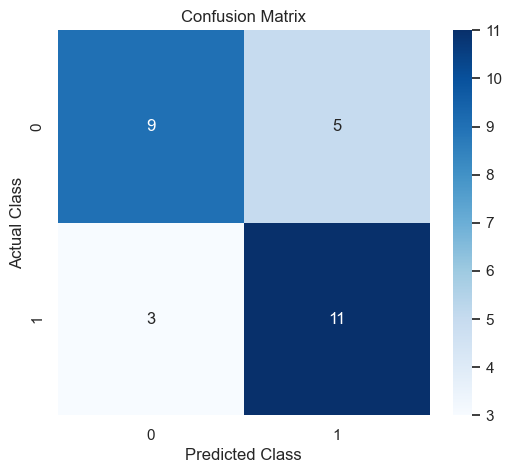

In [183]:
# Visualize confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

### Classification Performance Evaluation

The confusion matrix compares predicted student success categories with actual outcomes in the test dataset.

In this analysis, the positive class is defined as Successful students.

Accuracy measures the overall proportion of correct predictions. Precision measures how many predicted Successful students were actually Successful. Recall measures how effectively the model identifies Successful students. Specificity measures how effectively the model identifies At_Risk students.

The results suggest that the model performs reasonably well, although some misclassification still exists between Successful and At_Risk students.

### Limitation of Single Train-Test Split

One limitation of using a single random train-test split is that model performance may depend on the specific observations selected for training and testing. Different random splits could produce different evaluation results. Cross-validation would provide a more stable estimate of model performance.

## Task 8 - K-Means Clustering

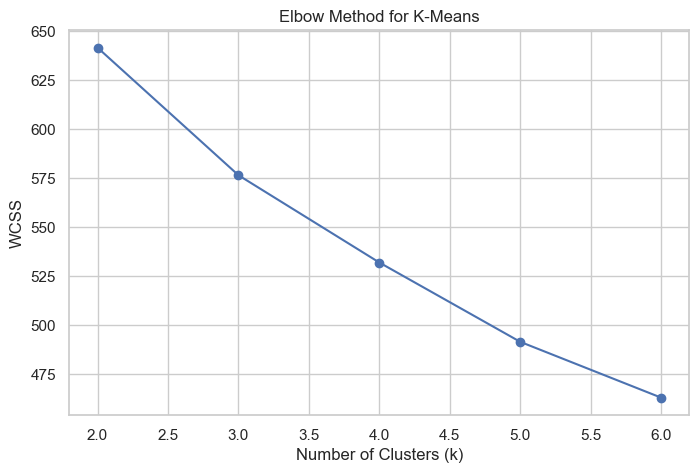

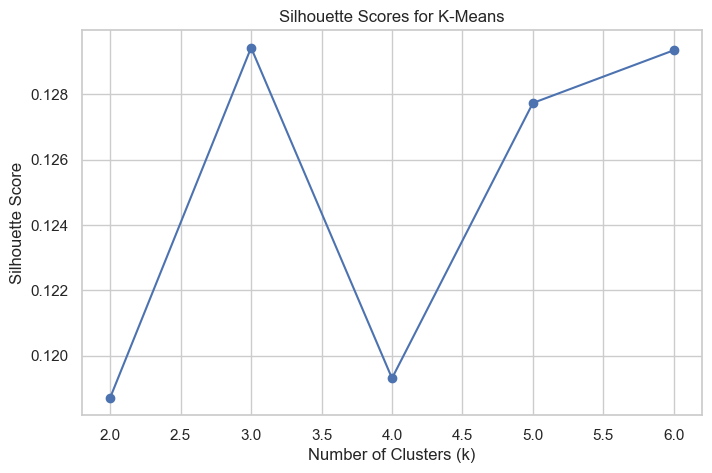

In [184]:
# Select numerical variables for clustering
# Exclude Overall_Score and Success_Status

cluster_features = df_hw3[[
    "Study_Hours",
    "Sleep_Hours",
    "Attendance_Rate",
    "LMS_Clicks",
    "Video_Minutes",
    "Forum_Posts",
    "Quiz_Score",
    "Project_Score"
]]


# Standardize variables before clustering

scaler = StandardScaler()

scaled_cluster_features = scaler.fit_transform(
    cluster_features
)


# Evaluate k values from 2 to 6

wcss = []

silhouette_scores = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        n_init=25,
        random_state=2026
    )

    cluster_labels = kmeans.fit_predict(
        scaled_cluster_features
    )

    wcss.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            scaled_cluster_features,
            cluster_labels
        )
    )


# Plot WCSS

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")

plt.show()


# Plot silhouette scores

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.show()

In [185]:
# Run final K-Means model

kmeans = KMeans(

    n_clusters=3,

    n_init=25,

    random_state=2026
)

df_hw3["Cluster"] = kmeans.fit_predict(
    scaled_cluster_features
)


# Check cluster sizes

df_hw3["Cluster"].value_counts()

Cluster
1    47
0    27
2    18
Name: count, dtype: int64

In [186]:
# Cluster centers in original scale

cluster_centers = pd.DataFrame(

    scaler.inverse_transform(
        kmeans.cluster_centers_
    ),

    columns=cluster_features.columns
)

cluster_centers

,Study_Hours,Sleep_Hours,Attendance_Rate,LMS_Clicks,Video_Minutes,Forum_Posts,Quiz_Score,Project_Score
0,14.674074,7.755556,0.867037,122.481481,294.925926,6.148148,72.814815,75.703704
1,11.821277,6.817021,0.653404,120.361702,248.531915,3.297872,76.127660,74.148936
2,15.200000,7.027778,0.781667,110.388889,232.611111,3.666667,61.666667,85.944444


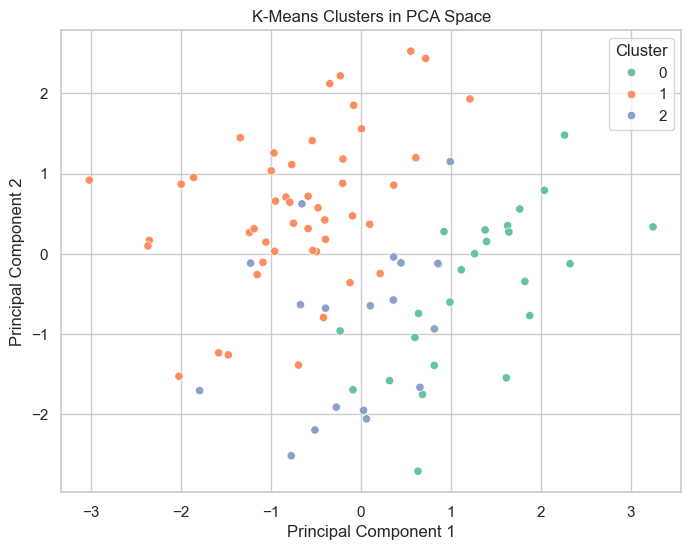

In [187]:
# PCA visualization of clusters

pca_cluster = PCA(n_components=2)

cluster_pca = pca_cluster.fit_transform(
    scaled_cluster_features
)

cluster_plot_df = pd.DataFrame({

    "PC1": cluster_pca[:, 0],

    "PC2": cluster_pca[:, 1],

    "Cluster": df_hw3["Cluster"]
})


plt.figure(figsize=(8, 6))

sns.scatterplot(

    data=cluster_plot_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2"
)

plt.title("K-Means Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [188]:
# Compare clusters with Success_Status

cluster_success_table = pd.crosstab(

    df_hw3["Cluster"],

    df_hw3["Success_Status"]
)

cluster_success_table

Success_Status,At_Risk,Successful
Cluster,,
0,11,16
1,29,18
2,9,9


### K-Means Clustering Interpretation

K-Means clustering was applied to standardized learning behavior variables in order to identify natural student groups without using the success labels.

The elbow curve and silhouette scores were used to evaluate different values of k. A reasonable cluster count was selected based on cluster compactness and separation.

Cluster centers suggest that the groups differ in learning behavior, engagement, and academic performance. Some clusters contain students with higher engagement and stronger academic outcomes, while others represent lower engagement or lower performance patterns.

The PCA visualization shows how clusters are distributed in reduced-dimensional space. Cross-tabulation with Success_Status suggests that some clusters are associated with higher proportions of Successful students.

## Final Conclusion

In [189]:
# Final dataset preview

df_hw3.head()

,Student_ID,Department,Study_Hours,Sleep_Hours,Attendance_Rate,LMS_Clicks,Video_Minutes,Forum_Posts,Teaching_Method,Quiz_Score,Project_Score,Advisor_Email,Overall_Score,Success_Status,Performance_Level,Engagement_Band,Valid_Email,Extracted_ID,Cluster
0,3001,AIE,14.90,8.6,0.68,110,338.0,2,Traditional,75.0,72.0,student3001@bahcesehir.edu.tr,72.0,At_Risk,Medium,Medium,True,3001,1
1,3002,SE,14.50,6.0,0.87,103,151.0,8,Traditional,75.0,89.0,student3002@bahcesehir.edu.tr,83.0,Successful,Medium,Low,True,3002,2
2,3003,SE,13.65,4.9,0.54,119,110.0,0,Flipped,67.0,78.0,student3003@bahcesehir.edu.tr,69.0,At_Risk,Low,Medium,True,3003,1
3,3004,Artificial Intelligence Engineering,10.30,8.7,0.51,107,256.0,2,Project-Based,76.0,79.0,student3004@bahcesehir.edu.tr,72.0,At_Risk,Medium,Low,True,3004,1
4,3005,aie,12.20,6.5,0.83,115,109.0,2,Flipped,70.0,83.0,student3005@bahcesehir.edu.tr,78.0,Successful,Medium,Medium,True,3005,2


In [190]:
# Final dataset information

df_hw3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Student_ID         92 non-null     int64   
 1   Department         92 non-null     object  
 2   Study_Hours        92 non-null     float64 
 3   Sleep_Hours        92 non-null     float64 
 4   Attendance_Rate    92 non-null     float64 
 5   LMS_Clicks         92 non-null     int64   
 6   Video_Minutes      92 non-null     float64 
 7   Forum_Posts        92 non-null     int64   
 8   Teaching_Method    92 non-null     object  
 9   Quiz_Score         92 non-null     float64 
 10  Project_Score      92 non-null     float64 
 11  Advisor_Email      92 non-null     object  
 12  Overall_Score      92 non-null     float64 
 13  Success_Status     92 non-null     object  
 14  Performance_Level  92 non-null     object  
 15  Engagement_Band    92 non-null     category
 16  Valid_Emai

In [191]:
# Final missing value check

df_hw3.isnull().sum()

Student_ID           0
Department           0
Study_Hours          0
Sleep_Hours          0
Attendance_Rate      0
LMS_Clicks           0
Video_Minutes        0
Forum_Posts          0
Teaching_Method      0
Quiz_Score           0
Project_Score        0
Advisor_Email        0
Overall_Score        0
Success_Status       0
Performance_Level    0
Engagement_Band      0
Valid_Email          0
Extracted_ID         0
Cluster              0
dtype: int64

This project applied a complete data science workflow to a synthetic learning analytics dataset. The process included data inspection, cleaning, feature engineering, exploratory analysis, PCA, classification modeling, performance evaluation, and unsupervised clustering. The results show that student engagement and academic behavior variables are strongly related to overall success outcomes.